# Classical random-imagery model training

## Purpose

This notebook executes the nine planned classical model variants on the fixed random-imagery
reconstruction protocols and publishes 27 immutable schema-v3 direction runs.

- **Cross-subject:** 141 train rows and 39 held-out rows with disjoint identities.
- **Identity-overlapping bidirectional cross-trial:** 81 train and 81 test rows in each direction.
- Every model performs its own train-only feature-family screening and grouped model selection.
- Classifier probabilities use grouped out-of-fold Platt calibration. Regression scores are
  clipped continuous outputs and are not probabilities.
- The summaries below validate training completeness. They are not interpreted as a pure model
  effect; the final protocol-separated comparison belongs to notebook 5.3.


## Reproducibility contract

All model and protocol execution goes through `execute_model_protocol`. `REUSE_EXISTING=True`
trains when the complete immutable run set is absent and safely reuses it otherwise. The feature
dataset and target table are built once because all nine configurations share the same source and
feature-extraction contract.


In [1]:
from pathlib import Path
import os
import sys
import time

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-classical-models")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from experiments.random_imagery import (
    PLANNED_MODEL_IDS,
    build_random_imagery_targets,
    execute_model_protocol,
    load_model_config,
    load_model_run,
)
from experiments.random_imagery.registry import get_model_spec
from utils.datasets import FeatureDataset

MODEL_CONFIG_PATHS = {
    "linear-svm-independent": Path("confs/experiments/linear_svm.yaml"),
    "ridge-classifier-independent": Path("confs/experiments/ridge_classifier.yaml"),
    "ridge-regression-independent": Path(
        "confs/experiments/ridge_regression_independent.yaml"
    ),
    "ridge-regression-multioutput": Path(
        "confs/experiments/ridge_regression_multioutput.yaml"
    ),
    "elastic-net-independent": Path(
        "confs/experiments/elastic_net_independent.yaml"
    ),
    "elastic-net-multioutput": Path(
        "confs/experiments/elastic_net_multioutput.yaml"
    ),
    "random-forest-independent": Path(
        "confs/experiments/random_forest_independent.yaml"
    ),
    "random-forest-multioutput": Path(
        "confs/experiments/random_forest_multioutput.yaml"
    ),
    "pls-regression-multioutput": Path(
        "confs/experiments/pls_regression_multioutput.yaml"
    ),
}
PROTOCOLS = ("cross-subject", "within-subject")
REUSE_EXISTING = True

assert tuple(MODEL_CONFIG_PATHS) == PLANNED_MODEL_IDS
MODEL_CONFIG_PATHS, PROTOCOLS, REUSE_EXISTING


({'linear-svm-independent': PosixPath('confs/experiments/linear_svm.yaml'),
  'ridge-classifier-independent': PosixPath('confs/experiments/ridge_classifier.yaml'),
  'ridge-regression-independent': PosixPath('confs/experiments/ridge_regression_independent.yaml'),
  'ridge-regression-multioutput': PosixPath('confs/experiments/ridge_regression_multioutput.yaml'),
  'elastic-net-independent': PosixPath('confs/experiments/elastic_net_independent.yaml'),
  'elastic-net-multioutput': PosixPath('confs/experiments/elastic_net_multioutput.yaml'),
  'random-forest-independent': PosixPath('confs/experiments/random_forest_independent.yaml'),
  'random-forest-multioutput': PosixPath('confs/experiments/random_forest_multioutput.yaml'),
  'pls-regression-multioutput': PosixPath('confs/experiments/pls_regression_multioutput.yaml')},
 ('cross-subject', 'within-subject'),
 True)

In [2]:
configs = {
    model_id: load_model_config(model_id, config_path=config_path)
    for model_id, config_path in MODEL_CONFIG_PATHS.items()
}
reference_config = configs[PLANNED_MODEL_IDS[0]]
shared_dataset = FeatureDataset(
    reference_config.dataset.dataset_dir,
    dataset_step_type=reference_config.dataset.recording_family,
    dataset_pattern_type=reference_config.dataset.pattern_type,
    config_path=reference_config.dataset.feature_config_path,
    cache_policy="disk",
    source_cache_policy="disk",
)
targets = build_random_imagery_targets(
    shared_dataset.samples,
    image_rows=reference_config.dataset.image_rows,
    image_columns=reference_config.dataset.image_columns,
)

for config in configs.values():
    assert config.dataset == reference_config.dataset
assert len(shared_dataset) == 180
assert targets.y.shape == (180, 36)
assert len(np.unique(targets.subject_ids)) == 33

pd.Series(
    {
        "source_rows": len(shared_dataset),
        "subjects": len(np.unique(targets.subject_ids)),
        "pixel_targets": targets.y.shape[1],
        "feature_config_hash": shared_dataset.config_hash,
    },
    name="real_corpus",
)


source_rows                         180
subjects                             33
pixel_targets                        36
feature_config_hash    fb8c5dcc8a1d3f30
Name: real_corpus, dtype: object

In [3]:
workflow_results = {}
timing_rows = []

for model_index, model_id in enumerate(PLANNED_MODEL_IDS, start=1):
    for protocol in PROTOCOLS:
        started = time.perf_counter()
        result = execute_model_protocol(
            protocol,
            config=configs[model_id],
            reuse_existing=REUSE_EXISTING,
            dataset=shared_dataset,
            targets=targets,
        )
        elapsed = time.perf_counter() - started
        workflow_results[(model_id, protocol)] = result
        timing_rows.append(
            {
                "model_id": model_id,
                "protocol": protocol,
                "elapsed_seconds": elapsed,
                "reused": result.reused,
                "direction_runs": len(result.run_dirs),
            }
        )
        print(
            f"[{model_index}/{len(PLANNED_MODEL_IDS)}] {model_id} | {protocol} | "
            f"{'reused' if result.reused else 'trained'} | {elapsed:.1f}s"
        )

timings_df = pd.DataFrame(timing_rows)
timings_df


[1/9] linear-svm-independent | cross-subject | reused | 0.1s


[1/9] linear-svm-independent | within-subject | reused | 0.4s
[2/9] ridge-classifier-independent | cross-subject | reused | 0.1s


[2/9] ridge-classifier-independent | within-subject | reused | 0.4s
[3/9] ridge-regression-independent | cross-subject | reused | 0.1s


[3/9] ridge-regression-independent | within-subject | reused | 0.4s
[4/9] ridge-regression-multioutput | cross-subject | reused | 0.1s


[4/9] ridge-regression-multioutput | within-subject | reused | 0.4s
[5/9] elastic-net-independent | cross-subject | reused | 0.1s


...

[6/9] elastic-net-multioutput | within-subject | reused | 0.4s
[7/9] random-forest-independent | cross-subject | reused | 0.1s


[7/9] random-forest-independent | within-subject | reused | 0.4s
[8/9] random-forest-multioutput | cross-subject | reused | 0.1s


[8/9] random-forest-multioutput | within-subject | reused | 0.4s
[9/9] pls-regression-multioutput | cross-subject | reused | 0.1s


[9/9] pls-regression-multioutput | within-subject | reused | 0.5s


,model_id,protocol,elapsed_seconds,reused,direction_runs
0,linear-svm-independent,cross-subject,0.138475,True,1
1,linear-svm-independent,within-subject,0.395694,True,2
2,ridge-classifier-independent,cross-subject,0.136157,True,1
3,ridge-classifier-independent,within-subject,0.384057,True,2
4,ridge-regression-independent,cross-subject,0.134497,True,1
5,ridge-regression-independent,within-subject,0.383665,True,2
6,ridge-regression-multioutput,cross-subject,0.113491,True,1
7,ridge-regression-multioutput,within-subject,0.362453,True,2
8,elastic-net-independent,cross-subject,0.142815,True,1
9,elastic-net-independent,within-subject,0.409534,True,2


In [4]:
validated_runs = []
for (model_id, protocol), workflow in workflow_results.items():
    spec = get_model_spec(model_id)
    expected_directions = 1 if protocol == "cross-subject" else 2
    assert len(workflow.run_dirs) == expected_directions
    for run_dir in workflow.run_dirs:
        run = load_model_run(run_dir)
        evaluation = run.evaluation
        audit = evaluation["split_audit"]
        split = evaluation["split"]
        assert run.manifest["schema_version"] == 3
        assert run.manifest["model_id"] == model_id
        assert run.manifest["topology"] == spec.topology
        assert run.results["pipeline_count"] == (
            36 if spec.topology == "independent" else 1
        )
        assert audit["has_forbidden_leakage"] is False
        assert audit["all_tasks_have_both_classes"] is True
        assert len(audit["overlapping_sample_keys"]) == 0
        assert len(audit["overlapping_seeds"]) == 0
        assert len(audit["overlapping_image_fingerprints"]) == 0
        if protocol == "cross-subject":
            assert (split["n_train_rows"], split["n_test_rows"]) == (141, 39)
            assert len(audit["overlapping_subjects"]) == 0
            assert audit["subject_contract_satisfied"] is True
        else:
            assert (split["n_train_rows"], split["n_test_rows"]) == (81, 81)
            assert len(audit["overlapping_subjects"]) == 27
            assert audit["trial_contract_satisfied"] is True
        validated_runs.append(
            {
                "model_id": model_id,
                "topology": spec.topology,
                "score_semantics": spec.score_semantics,
                "protocol": protocol,
                "direction": evaluation["direction"]["name"],
                "n_train": split["n_train_rows"],
                "n_test": split["n_test_rows"],
                "selected_features": "+".join(
                    evaluation["selected_feature_family"]
                ),
                "pipeline_count": run.results["pipeline_count"],
                "balanced_accuracy": evaluation["model_metrics"][
                    "mean_balanced_accuracy"
                ],
                "ci_low": evaluation["model_bootstrap"]["lower"],
                "ci_high": evaluation["model_bootstrap"]["upper"],
                "run_dir": str(run.run_dir),
            }
        )

runs_df = pd.DataFrame(validated_runs)
assert len(runs_df) == 27
assert runs_df["run_dir"].nunique() == 27
runs_df


,model_id,topology,score_semantics,protocol,direction,n_train,n_test,selected_features,pipeline_count,balanced_accuracy,ci_low,ci_high,run_dir
0,linear-svm-independent,independent,calibrated_probability,cross-subject,cross-subject,141,39,lbp,36,0.493336,0.460514,0.526093,artifacts/experiments/random-imagery/linear-sv...
1,linear-svm-independent,independent,calibrated_probability,within-subject,trial-1-to-trial-2,81,81,lbp,36,0.503030,0.490595,0.515541,artifacts/experiments/random-imagery/linear-sv...
2,linear-svm-independent,independent,calibrated_probability,within-subject,trial-2-to-trial-1,81,81,time+spectral,36,0.512548,0.500744,0.523589,artifacts/experiments/random-imagery/linear-sv...
3,ridge-classifier-independent,independent,calibrated_probability,cross-subject,cross-subject,141,39,lgp,36,0.502154,0.487549,0.523581,artifacts/experiments/random-imagery/ridge-cla...
4,ridge-classifier-independent,independent,calibrated_probability,within-subject,trial-1-to-trial-2,81,81,log_covariance,36,0.503065,0.491212,0.515091,artifacts/experiments/random-imagery/ridge-cla...
5,ridge-classifier-independent,independent,calibrated_probability,within-subject,trial-2-to-trial-1,81,81,time+spectral,36,0.513105,0.501694,0.523925,artifacts/experiments/random-imagery/ridge-cla...
6,ridge-regression-independent,independent,clipped_regression,cross-subject,cross-subject,141,39,lgp,36,0.518382,0.486733,0.561786,artifacts/experiments/random-imagery/ridge-reg...
7,ridge-regression-independent,independent,clipped_regression,within-subject,trial-1-to-trial-2,81,81,log_covariance,36,0.501808,0.483990,0.520476,artifacts/experiments/random-imagery/ridge-reg...
8,ridge-regression-independent,independent,clipped_regression,within-subject,trial-2-to-trial-1,81,81,time+spectral,36,0.496848,0.474530,0.516339,artifacts/experiments/random-imagery/ridge-reg...
9,ridge-regression-multioutput,multioutput,clipped_regression,cross-subject,cross-subject,141,39,time+spectral,1,0.497668,0.472546,0.521114,artifacts/experiments/random-imagery/ridge-reg...


In [5]:
reuse_rows = []
for model_id in PLANNED_MODEL_IDS:
    for protocol in PROTOCOLS:
        reused = execute_model_protocol(
            protocol,
            config=configs[model_id],
            reuse_existing=True,
            dataset=shared_dataset,
            targets=targets,
        )
        assert reused.reused is True
        reuse_rows.append(
            {
                "model_id": model_id,
                "protocol": protocol,
                "validated_direction_runs": len(reused.run_dirs),
            }
        )

reuse_df = pd.DataFrame(reuse_rows)
assert reuse_df["validated_direction_runs"].sum() == 27
reuse_df


,model_id,protocol,validated_direction_runs
0,linear-svm-independent,cross-subject,1
1,linear-svm-independent,within-subject,2
2,ridge-classifier-independent,cross-subject,1
3,ridge-classifier-independent,within-subject,2
4,ridge-regression-independent,cross-subject,1
5,ridge-regression-independent,within-subject,2
6,ridge-regression-multioutput,cross-subject,1
7,ridge-regression-multioutput,within-subject,2
8,elastic-net-independent,cross-subject,1
9,elastic-net-independent,within-subject,2


## Descriptive completeness view

This chart is a run-level reasonableness check, not the final model comparison. Cross-subject and
cross-trial directions have different generalization meanings and are not averaged together.


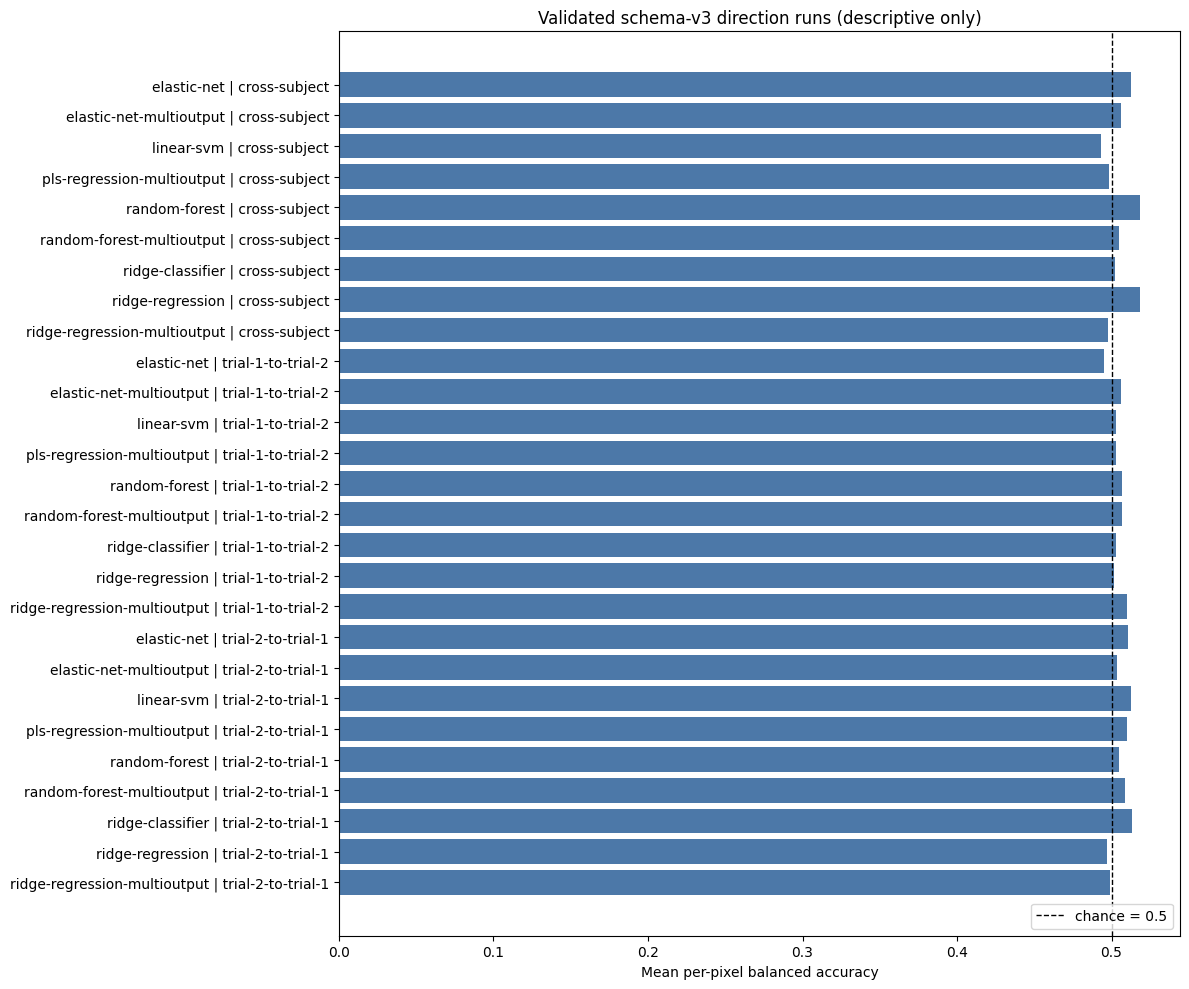

In [6]:
plot_df = runs_df.copy()
plot_df["run_label"] = (
    plot_df["model_id"].str.replace("-independent", "", regex=False)
    + " | "
    + plot_df["direction"]
)
plot_df = plot_df.sort_values(["protocol", "direction", "model_id"])

fig, ax = plt.subplots(figsize=(12, 10))
y = np.arange(len(plot_df))
ax.barh(y, plot_df["balanced_accuracy"], color="#4C78A8")
ax.axvline(0.5, color="black", linestyle="--", linewidth=1, label="chance = 0.5")
ax.set_yticks(y, labels=plot_df["run_label"])
ax.set_xlabel("Mean per-pixel balanced accuracy")
ax.set_title("Validated schema-v3 direction runs (descriptive only)")
ax.invert_yaxis()
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()


In [7]:
assert len(workflow_results) == 18
assert len(runs_df) == 27
assert not runs_df[["balanced_accuracy", "ci_low", "ci_high"]].isna().any().any()
assert np.isfinite(
    runs_df[["balanced_accuracy", "ci_low", "ci_high"]].to_numpy()
).all()
assert set(runs_df["score_semantics"]) == {
    "calibrated_probability",
    "clipped_regression",
}
print("CLASSICAL_MODELS_TRAINING_VERIFIED")


CLASSICAL_MODELS_TRAINING_VERIFIED
